## Housing Price Prediction

- Download hosuing dataset in the tarball format
- Extract dataset file into dataset folder which is created or pre-existed
- Load extracted csv dataset file using pandas read_csv method

In [15]:
from pathlib import Path
import pandas as pd
import tarfile
import urllib.request

def load_housing_data():
    tarball_path = Path("datasets/housing.tgz")
    if not tarball_path.is_file():
        Path("datasets").mkdir(parents=True, exist_ok=True)
    url = "https://github.com/ageron/data/raw/main/housing.tgz"
    urllib.request.urlretrieve(url, tarball_path)
    with tarfile.open(tarball_path) as housing_tarball:
        housing_tarball.extractall(path="datasets")
    return pd.read_csv(Path("datasets/housing/housing.csv"))

housing = load_housing_data()
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [16]:
housing.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


- Above shown list of features of housing dataset 
- Only ocean proximity is the type of string, all other features are floating 64 bit numbers

In [23]:
val_counts = housing['ocean_proximity'].value_counts()
val_counts

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

- Looking at the bar chart, we can see majority of houses are located inland or one-hour distance from the ocean

<BarContainer object of 5 artists>

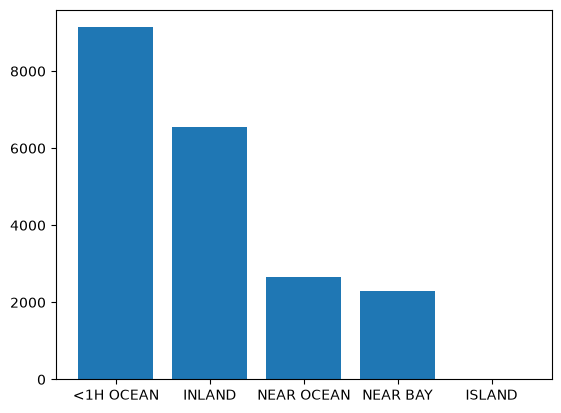

In [22]:
import matplotlib.pyplot as plt
plt.bar(val_counts.index, val_counts)

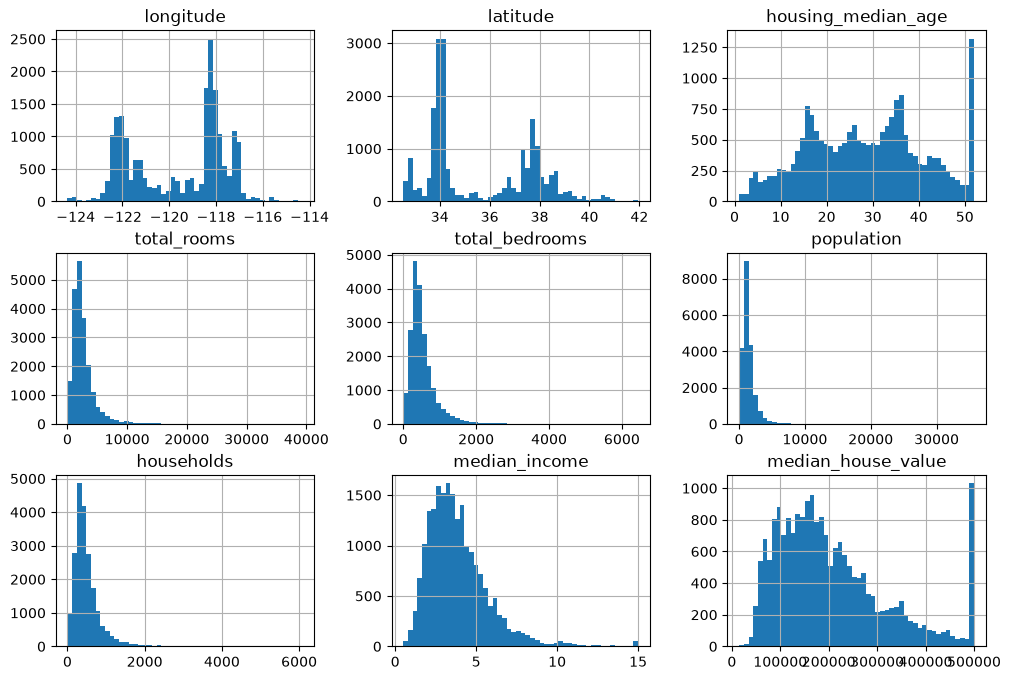

In [24]:
housing.hist(bins=50, figsize=(12, 8))
plt.show()

- `median_income` feature does not look like it is US dollars because house prices is max is 15. So we can assume these numbers represents x $10.000
- these does not mean the data is wrong but we should notice these transformation/patterns/caps
- Not only median income, but also median age and median value features also look like capped to 50 and $500K respectively
- All attributes has very different scales for example, age is 0-50, while house value is in the range of 0-500K
- When it comes to skeewness of histograms, we can see most of them are skewed right (right side of graph shape is signiifcantly bigger than rest of it, that is, many ML models struggle to learn patterns)  


##### So we explored some patterns about housing dataset which gives important information to use later in preprocessing stage to prepare our dataset for training models to predict most precice predictions  

- One job should be done right before data preprocessing is to split data into train and test subsets (optionally validation set too). 
- We will do some preprocess training set by applying cleaning and transformations before choosing the right model to train on. 

In [29]:
import numpy as np
def shuffle_split_data(data, test_ratio):
    shuffled_indices = np.random.permutation(len(data))
    test_set_size = int(len(data) * test_ratio)
    test_indices = shuffled_indices[:test_set_size]
    train_indices = shuffled_indices[test_set_size:]
    return data.iloc[train_indices], data.iloc[test_indices]

- Here we made our basic shuflled data splitter function
- However, we can use built-in `train_test_split` function provided in `sklearn.model_selection`

16512 by 4128


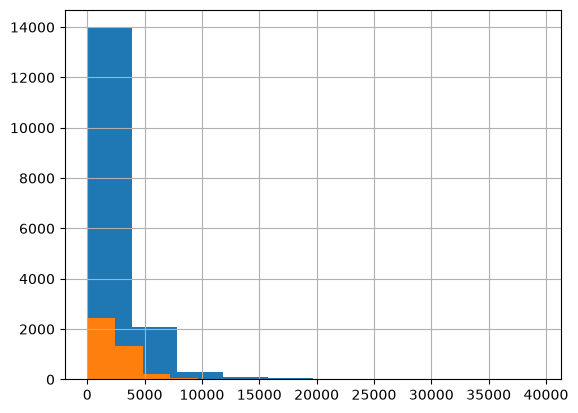

In [ ]:
train_set, test_set = shuffle_split_data(housing, 0.2)
print(len(train_set), "by", len(test_set))


fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=True)

train_set["total_rooms"].hist(ax=axes[0], bins=50)
axes[0].set_title("Train set")

test_set["total_rooms"].hist(ax=axes[1], bins=50)
axes[1].set_title("Test set")

plt.tight_layout()
plt.show()

In [9]:
from sklearn.cluster import KMeans
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics.pairwise import rbf_kernel

class ClusterSimilarity(BaseEstimator, TransformerMixin):
    def __init__(self, n_clusters=10, gamma=1.0, random_state=None):
        self.n_clusters = n_clusters
        self.gamma = gamma
        self.random_state = random_state
    def fit(self, X, y=None, sample_weight=None):
        self.kmeans_ = KMeans(self.n_clusters, random_state=self.random_state) 
        self.kmeans_.fit(X, sample_weight=sample_weight)
        return self # always return self!
    def transform(self, X):
        return rbf_kernel(X, self.kmeans_.cluster_centers_, gamma=self.gamma)
    def get_feature_names_out(self, names=None):
        return [f"Cluster {i} similarity" for i in range(self.n_clusters)]

In [10]:
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.compose import ColumnTransformer

def column_ratio(X):
    return X[:, [0]] / X[:, [1]]

def ratio_pipeline(name=None):
    return make_pipeline(
        SimpleImputer(strategy="median"),
        FunctionTransformer(column_ratio,   validate=False, feature_names_out=lambda self, feature_names: [name]),
        StandardScaler()
    )
    
log_pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    FunctionTransformer(
        np.log,
        validate=False,
        feature_names_out="one-to-one"
    ),
    StandardScaler()
)

cat_pipeline = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    OneHotEncoder(handle_unknown="ignore")
)

cluster_simil = ClusterSimilarity(n_clusters=10, gamma=1.0, random_state=42)

default_num_pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler()
)

# Hamma transformerlarni birlashtirish
preprocessor = ColumnTransformer([
    ("bedrooms_ratio", ratio_pipeline(name="bedrooms_ratio"), ["total_bedrooms", "total_rooms"]),
    ("rooms_per_house", ratio_pipeline(name="rooms_per_house"), ["total_rooms", "households"]),
    ("people_per_house", ratio_pipeline(name="people_per_house"), ["population", "households"]),
    ("log", log_pipeline, ["total_bedrooms", "total_rooms", "population", "households", "median_income"]),
    ("geo", cluster_simil, ["latitude", "longitude"]),
    ("cat", cat_pipeline, make_column_selector(dtype_include=object))],
    remainder=default_num_pipeline
)

In [11]:
housing = pd.read_csv("https://raw.githubusercontent.com/ageron/data/main/housing/housing.csv")
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [12]:
housing_prepared = preprocessor.fit_transform(housing)
housing_prepared.shape



(20640, 25)

In [13]:
preprocessor.get_feature_names_out()

array(['bedrooms_ratio__bedrooms_ratio',
       'rooms_per_house__rooms_per_house',
       'people_per_house__people_per_house', 'log__total_bedrooms',
       'log__total_rooms', 'log__population', 'log__households',
       'log__median_income', 'geo__Cluster 0 similarity',
       'geo__Cluster 1 similarity', 'geo__Cluster 2 similarity',
       'geo__Cluster 3 similarity', 'geo__Cluster 4 similarity',
       'geo__Cluster 5 similarity', 'geo__Cluster 6 similarity',
       'geo__Cluster 7 similarity', 'geo__Cluster 8 similarity',
       'geo__Cluster 9 similarity', 'cat__ocean_proximity_<1H OCEAN',
       'cat__ocean_proximity_INLAND', 'cat__ocean_proximity_ISLAND',
       'cat__ocean_proximity_NEAR BAY', 'cat__ocean_proximity_NEAR OCEAN',
       'remainder__housing_median_age', 'remainder__median_house_value'],
      dtype=object)

In [ ]:
from sklearn.linear_model import LinearRegression

lin_reg = make_pipeline(
    preprocessor,
    LinearRegression()
)
lin_reg.fit(housing, housing_labels)